# 03 - Modelo base ingenuo estacional

Este notebook define el **modelo base ingenuo estacional** que se utilizará como referencia frente a los modelos de aprendizaje supervisado.

El modelo no se entrena en sentido paramétrico; se define mediante una regla de persistencia diaria. Esto es, para cada instante objetivo, se predice la concentración de O3 observada en la misma hora del día anterior, lo que matemáticamente se puede definir como:

$$
\hat{y}_{\tau} = y_{\tau - 24}
$$

donde $\tau$ es el instante objetivo que se quiere predecir.

Esta idea equivale al concepto de *last equivalent date* o *seasonal naive forecasting* utilizado en referencias de forecasting y, concretamente, en la clase `ForecasterEquivalentDate` de `skforecast`: el pronóstico se toma de una fecha histórica equivalente, definida por un desplazamiento temporal. En nuestro caso, el desplazamiento es de 24 horas.

> Nota metodológica: aunque `skforecast` ofrece una clase específica para este tipo de referencia, aquí se aplica la regla de forma explícita a partir de los datasets de modelado generados en el notebook `02_modeling_dataset_features.ipynb`. De esta forma, se mantiene la trazabilidad por horizonte y se puede comprobar con claridad que no se introduzca fuga temporal.


## Objetivos del notebook

1. Cargar los datasets de modelado para los horizontes de 1, 4, 12 y 24 horas
2. Aplicar la regla de persistencia diaria utilizando la columna `o3_prev_day_same_hour`
3. Verificar que la predicción del modelo base es causal para todos los horizontes considerados
4. Calcular métricas puntuales MAE y RMSE en calibración y validación
5. Guardar las predicciones y las métricas para su uso posterior en la comparación puntual y en la calibración mediante `split conformal`.

El conjunto de prueba de 2025 no se evalúa en este notebook; queda reservado para la evaluación final del modelo seleccionado.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)


In [ ]:
# Configuración general del notebook
# ==============================================================================
# El notebook puede ejecutarse desde la carpeta notebooks/ o desde la raíz del
# repositorio. Esta función localiza la raíz de forma dinámica.

def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_PREDICTIONS_DIR = PROJECT_ROOT / "reports" / "predictions"

for path in [REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_PREDICTIONS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

HORIZONS_HOURS: List[int] = [1, 4, 12, 24]
MODEL_NAME = "baseline_seasonal_naive"
BASELINE_COLUMN = "o3_prev_day_same_hour"
TARGET_COLUMN = "y"

# En esta fase NO se evalúa el conjunto de prueba (2025).
# El test se reservará para la evaluación final del modelo seleccionado.
EVAL_SPLITS: List[str] = ["calibration", "validation"]
INCLUDE_TEST = False

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datasets de modelado: {DATA_MODELING_DIR}")
print(f"Predicciones: {REPORTS_PREDICTIONS_DIR}")
print(f"Tablas: {REPORTS_TABLES_DIR}")
print(f"Figuras: {REPORTS_FIGURES_DIR}")


Raíz del proyecto: C:\trabajo_github
Datasets de modelado: C:\trabajo_github\data\modeling
Predicciones: C:\trabajo_github\reports\predictions
Tablas: C:\trabajo_github\reports\tables
Figuras: C:\trabajo_github\reports\figures


## Carga de los datasets de modelado por horizonte

Los datasets de modelado ya contienen, para cada horizonte, la estructura:

$$
X_t \rightarrow y_{t+h}
$$

Donde:

- `origin_timestamp` es el instante desde el que se emite la predicción
- `target_timestamp` es el instante objetivo
- `y` es el valor observado de O3 en el instante objetivo
- `o3_prev_day_same_hour` es el valor de O3 en la misma hora del día anterior al objetivo

Por tanto, para el modelo base ingenuo estacional, se tiene:

$$
\hat{y}_{t+h} = y_{t+h-24}
$$


In [3]:
def load_modeling_dataset(horizon: int) -> pd.DataFrame:
    """Carga el dataset de modelado correspondiente a un horizonte."""
    file_path = DATA_MODELING_DIR / f"modeling_h{horizon:02d}.parquet"
    if not file_path.exists():
        raise FileNotFoundError(
            f"No se encontró el dataset de modelado para h={horizon}: {file_path}. "
            "Debe ejecutarse en primer lugar el notebook 02_modeling_dataset_features.ipynb."
        )

    df = pd.read_parquet(file_path)

    required_columns = {
        "origin_timestamp",
        "target_timestamp",
        "split",
        TARGET_COLUMN,
        BASELINE_COLUMN,
    }
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(
            f"El dataset de h={horizon} no contiene las columnas requeridas: "
            f"{sorted(missing_columns)}"
        )

    df = df.copy()
    df["origin_timestamp"] = pd.to_datetime(df["origin_timestamp"])
    df["target_timestamp"] = pd.to_datetime(df["target_timestamp"])
    df["horizon"] = horizon

    return df


modeling_by_horizon: Dict[int, pd.DataFrame] = {
    horizon: load_modeling_dataset(horizon)
    for horizon in HORIZONS_HOURS
}

loaded_summary = pd.DataFrame([
    {
        "horizon": horizon,
        "n_rows": len(df),
        "target_start": df["target_timestamp"].min(),
        "target_end": df["target_timestamp"].max(),
        "splits": ", ".join(sorted(df["split"].dropna().unique())),
    }
    for horizon, df in modeling_by_horizon.items()
])

display(loaded_summary)


,horizon,n_rows,target_start,target_end,splits
0,1,50941,2020-01-01 01:00:00,2025-12-31 23:00:00,"calibration, test, train, validation"
1,4,50938,2020-01-01 04:00:00,2025-12-31 23:00:00,"calibration, test, train, validation"
2,12,50930,2020-01-01 12:00:00,2025-12-31 23:00:00,"calibration, test, train, validation"
3,24,50918,2020-01-02 00:00:00,2025-12-31 23:00:00,"calibration, test, train, validation"


## Comprobación de causalidad

La predicción del modelo base se obtiene a partir de la misma hora del día anterior al instante objetivo. Para que esto no introduzca fuga temporal, dicho instante debe ser anterior o igual al `origin_timestamp` desde el que se emite la predicción.

Para cada horizonte se comprueba que se cumpla:

$$
\tau - 24 \leq t
$$

siendo $\tau = t + h$.

En los horizontes considerados, esto equivale a:

- h = 1: se usa un valor 23 horas anterior al origen
- h = 4: se usa un valor 20 horas anterior al origen
- h = 12: se usa un valor 12 horas anterior al origen
- h = 24: se usa el valor observado en el propio origen

Todos estos valores se encuentran disponibles en el momento de emitir la predicción.


In [4]:
def check_baseline_causality(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """Comprueba que la referencia diaria del baseline no utilice información futura."""
    expected_target = df["origin_timestamp"] + pd.to_timedelta(horizon, unit="h")
    bad_target = expected_target != df["target_timestamp"]
    if bad_target.any():
        raise AssertionError(
            f"Se detectaron {bad_target.sum()} filas en h={horizon} donde "
            "target_timestamp no coincide con origin_timestamp + horizonte."
        )

    check = df[["origin_timestamp", "target_timestamp", "split"]].copy()
    check["horizon"] = horizon
    check["baseline_source_timestamp"] = check["target_timestamp"] - pd.Timedelta(hours=24)
    check["source_is_available_at_origin"] = (
        check["baseline_source_timestamp"] <= check["origin_timestamp"]
    )
    check["source_lag_from_origin_h"] = (
        (check["origin_timestamp"] - check["baseline_source_timestamp"])
        / pd.Timedelta(hours=1)
    )

    if not check["source_is_available_at_origin"].all():
        problematic = check.loc[~check["source_is_available_at_origin"]].head()
        raise ValueError(
            f"Fuga temporal detectada en h={horizon}. Primeros casos problemáticos:\n{problematic}"
        )

    return check

causality_checks = []
for horizon, df_h in modeling_by_horizon.items():
    causality_checks.append(check_baseline_causality(df_h, horizon))

causality_checks_all = pd.concat(causality_checks, ignore_index=True)
causality_summary = (
    causality_checks_all
    .groupby("horizon", as_index=False)
    .agg(
        n_rows=("horizon", "size"),
        min_source_lag_h=("source_lag_from_origin_h", "min"),
        max_source_lag_h=("source_lag_from_origin_h", "max"),
        all_sources_available=("source_is_available_at_origin", "all"),
    )
)

display(causality_summary)


,horizon,n_rows,min_source_lag_h,max_source_lag_h,all_sources_available
0,1,50941,23.0,23.0,True
1,4,50938,20.0,20.0,True
2,12,50930,12.0,12.0,True
3,24,50918,0.0,0.0,True


## Definición del modelo base ingenuo estacional

El modelo base ingenuo estacional no requiere del ajuste de parámetros: para cada fila evaluable, la predicción se toma directamente de `o3_prev_day_same_hour`.

Se calculan predicciones para las posteriores calibración y validación. El conjunto de calibración será necesario para `split conformal`, y el de validación servirá para la comparación inicial entre modelos.


In [5]:
def apply_daily_persistence_baseline(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica la regla de persistencia diaria del modelo base."""
    pred_df = df[[
        "horizon",
        "split",
        "origin_timestamp",
        "target_timestamp",
        TARGET_COLUMN,
        BASELINE_COLUMN,
    ]].copy()

    pred_df = pred_df.rename(
        columns={
            TARGET_COLUMN: "y_true",
            BASELINE_COLUMN: "y_pred",
        }
    )

    pred_df["model"] = MODEL_NAME
    pred_df["baseline_rule"] = "same_hour_previous_day"
    pred_df["baseline_source_timestamp"] = pred_df["target_timestamp"] - pd.Timedelta(hours=24)
    pred_df["source_lag_from_origin_h"] = (
        (pred_df["origin_timestamp"] - pred_df["baseline_source_timestamp"])
        / pd.Timedelta(hours=1)
    )

    # Una predicción es evaluable solo si existen tanto el valor real como la referencia diaria.
    pred_df["is_evaluable"] = pred_df[["y_true", "y_pred"]].notna().all(axis=1)
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    pred_df["abs_error"] = pred_df["residual"].abs()
    pred_df["squared_error"] = pred_df["residual"] ** 2

    return pred_df

all_predictions: List[pd.DataFrame] = []

for horizon, df_h in modeling_by_horizon.items():
    eval_splits = list(EVAL_SPLITS)
    if INCLUDE_TEST and "test" not in eval_splits:
        eval_splits.append("test")

    # Se excluye explícitamente el conjunto de prueba para mantenerlo intacto.
    df_h_eval = df_h.loc[df_h["split"].isin(eval_splits)].copy()
    pred_h = apply_daily_persistence_baseline(df_h_eval)

    output_path = REPORTS_PREDICTIONS_DIR / f"{MODEL_NAME}_h{horizon:02d}.parquet"
    pred_h.to_parquet(output_path, index=False)
    print(f"h={horizon:02d}: predicciones guardadas en {output_path}")

    all_predictions.append(pred_h)

baseline_predictions = pd.concat(all_predictions, ignore_index=True)
display(baseline_predictions.head())


h=01: predicciones guardadas en C:\trabajo_github\reports\predictions\baseline_seasonal_naive_h01.parquet
h=04: predicciones guardadas en C:\trabajo_github\reports\predictions\baseline_seasonal_naive_h04.parquet
h=12: predicciones guardadas en C:\trabajo_github\reports\predictions\baseline_seasonal_naive_h12.parquet
h=24: predicciones guardadas en C:\trabajo_github\reports\predictions\baseline_seasonal_naive_h24.parquet


,horizon,split,origin_timestamp,target_timestamp,y_true,y_pred,model,baseline_rule,baseline_source_timestamp,source_lag_from_origin_h,is_evaluable,residual,abs_error,squared_error
0,1,calibration,2022-12-31 23:00:00,2023-01-01 00:00:00,1.0,17.0,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 00:00:00,23.0,True,-16.0,16.0,256.0
1,1,calibration,2023-01-01 00:00:00,2023-01-01 01:00:00,1.0,25.0,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 01:00:00,23.0,True,-24.0,24.0,576.0
2,1,calibration,2023-01-01 01:00:00,2023-01-01 02:00:00,1.0,17.0,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 02:00:00,23.0,True,-16.0,16.0,256.0
3,1,calibration,2023-01-01 02:00:00,2023-01-01 03:00:00,1.0,32.0,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 03:00:00,23.0,True,-31.0,31.0,961.0
4,1,calibration,2023-01-01 03:00:00,2023-01-01 04:00:00,1.0,46.0,baseline_seasonal_naive,same_hour_previous_day,2022-12-31 04:00:00,23.0,True,-45.0,45.0,2025.0


## Métricas puntuales

Se calculan las métricas MAE y RMSE sobre las observaciones evaluables. Las filas con `NaN` en el valor real o en la predicción del modelo base se documentan, pero no se usan para el cálculo de dichas métricas.

La comparación principal se realizará sobre el conjunto de validación de 2024. Aun así, se guardan también métricas para calibración, porque podrían resultar útiles para interpretar la posterior calibración conforme.


In [6]:
def compute_point_metrics(group: pd.DataFrame) -> dict:
    """Calcula métricas puntuales para una combinación horizonte/split."""
    valid = group.loc[group["is_evaluable"]].copy()

    output = {
        "model": MODEL_NAME,
        "horizon": int(group["horizon"].iloc[0]),
        "split": group["split"].iloc[0],
        "n_rows": int(len(group)),
        "n_evaluated": int(len(valid)),
        "n_missing_y": int(group["y_true"].isna().sum()),
        "n_missing_pred": int(group["y_pred"].isna().sum()),
        "evaluated_pct": float(len(valid) / len(group) * 100) if len(group) else np.nan,
    }

    if valid.empty:
        output.update({
            "mae": np.nan,
            "rmse": np.nan,
            "mean_error": np.nan,
            "median_abs_error": np.nan,
        })
        return output

    errors = valid["y_true"] - valid["y_pred"]
    abs_errors = errors.abs()

    output.update({
        "mae": float(abs_errors.mean()),
        "rmse": float(np.sqrt((errors ** 2).mean())),
        "mean_error": float(errors.mean()),
        "median_abs_error": float(np.median(abs_errors)),
    })

    return output

metrics_rows = []
for (horizon, split), group in baseline_predictions.groupby(["horizon", "split"], sort=True):
    metrics_rows.append(compute_point_metrics(group))

baseline_metrics = pd.DataFrame(metrics_rows).sort_values(["split", "horizon"]).reset_index(drop=True)

display(baseline_metrics)


,model,horizon,split,n_rows,n_evaluated,n_missing_y,n_missing_pred,evaluated_pct,mae,rmse,mean_error,median_abs_error
0,baseline_seasonal_naive,1,calibration,8607,8474,0,133,98.454746,16.183384,21.201563,-0.021713,13.0
1,baseline_seasonal_naive,4,calibration,8607,8474,0,133,98.454746,16.183384,21.201563,-0.021713,13.0
2,baseline_seasonal_naive,12,calibration,8607,8474,0,133,98.454746,16.183384,21.201563,-0.021713,13.0
3,baseline_seasonal_naive,24,calibration,8607,8474,0,133,98.454746,16.183384,21.201563,-0.021713,13.0
4,baseline_seasonal_naive,1,validation,8437,8265,0,172,97.961361,16.664005,21.847843,-0.064852,13.0
5,baseline_seasonal_naive,4,validation,8437,8265,0,172,97.961361,16.664005,21.847843,-0.064852,13.0
6,baseline_seasonal_naive,12,validation,8437,8265,0,172,97.961361,16.664005,21.847843,-0.064852,13.0
7,baseline_seasonal_naive,24,validation,8437,8265,0,172,97.961361,16.664005,21.847843,-0.064852,13.0


In [7]:
def summarize_predictions(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Genera una tabla de control con el número de filas, las observaciones evaluables,
    el rango temporal y el porcentaje de valores ausentes por horizonte y bloque cronológico."""
    rows = []

    for (horizon, split), group in pred_df.groupby(["horizon", "split"], sort=True):
        valid_mask = group["y_true"].notna() & group["y_pred"].notna()
        rows.append({
            "model": MODEL_NAME,
            "horizon": int(horizon),
            "split": split,
            "n_rows": int(len(group)),
            "n_evaluable": int(valid_mask.sum()),
            "target_start": group["target_timestamp"].min(),
            "target_end": group["target_timestamp"].max(),
            "missing_y_pct": float(group["y_true"].isna().mean() * 100),
            "missing_pred_pct": float(group["y_pred"].isna().mean() * 100),
        })

    return pd.DataFrame(rows)


baseline_summary = summarize_predictions(baseline_predictions)
display(baseline_summary)


,model,horizon,split,n_rows,n_evaluable,target_start,target_end,missing_y_pct,missing_pred_pct
0,baseline_seasonal_naive,1,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.0,1.545254
1,baseline_seasonal_naive,1,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.0,2.038639
2,baseline_seasonal_naive,4,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.0,1.545254
3,baseline_seasonal_naive,4,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.0,2.038639
4,baseline_seasonal_naive,12,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.0,1.545254
5,baseline_seasonal_naive,12,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.0,2.038639
6,baseline_seasonal_naive,24,calibration,8607,8474,2023-01-01,2023-12-31 23:00:00,0.0,1.545254
7,baseline_seasonal_naive,24,validation,8437,8265,2024-01-01,2024-12-31 23:00:00,0.0,2.038639


## Guardado de las métricas y de las tablas de control

Las predicciones por horizonte ya se han guardado en `reports/predictions`. En esta sección se guardan las métricas y tablas de control en formato CSV, lo que podría ser útil para una revisión visual.


In [8]:
metrics_path = REPORTS_TABLES_DIR / "baseline_point_metrics.csv"
summary_path = REPORTS_TABLES_DIR / "baseline_prediction_summary.csv"
causality_path = REPORTS_TABLES_DIR / "baseline_causality_check.csv"
sample_path = REPORTS_TABLES_DIR / "baseline_predictions_sample.csv"

baseline_metrics.to_csv(metrics_path, index=False)
baseline_summary.to_csv(summary_path, index=False)
causality_summary.to_csv(causality_path, index=False)
baseline_predictions.head(200).to_csv(sample_path, index=False)

print(f"Métricas guardadas en: {metrics_path}")
print(f"Resumen guardado en: {summary_path}")
print(f"Comprobación de causalidad guardada en: {causality_path}")
print(f"Muestra de predicciones guardada en: {sample_path}")


Métricas guardadas en: C:\trabajo_github\reports\tables\baseline_point_metrics.csv
Resumen guardado en: C:\trabajo_github\reports\tables\baseline_prediction_summary.csv
Comprobación de causalidad guardada en: C:\trabajo_github\reports\tables\baseline_causality_check.csv
Muestra de predicciones guardada en: C:\trabajo_github\reports\tables\baseline_predictions_sample.csv


## Evolución de las métricas MAE y RMSE en el conjunto de validación

La siguiente figura resume la evolución de MAE y RMSE en el conjunto de validación de 2024. No sustituye a la comparación final con el resto de modelos, pero permite comprobar si el comportamiento del modelo base es el que cabría esperar.


Figura guardada en: C:\trabajo_github\reports\figures\fig_baseline_point_metrics_validation.png


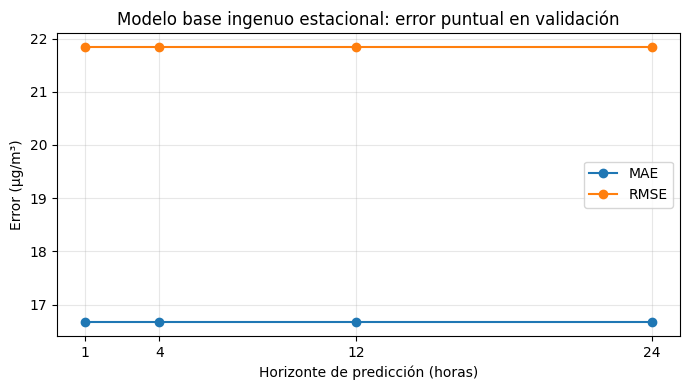

In [9]:
validation_metrics = baseline_metrics.loc[baseline_metrics["split"] == "validation"].copy()

if not validation_metrics.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(validation_metrics["horizon"], validation_metrics["mae"], marker="o", label="MAE")
    ax.plot(validation_metrics["horizon"], validation_metrics["rmse"], marker="o", label="RMSE")
    ax.set_title("Modelo base ingenuo estacional: error puntual en validación")
    ax.set_xlabel("Horizonte de predicción (horas)")
    ax.set_ylabel("Error (µg/m³)")
    ax.set_xticks(HORIZONS_HOURS)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    figure_path = REPORTS_FIGURES_DIR / "fig_baseline_point_metrics_validation.png"
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    print(f"Figura guardada en: {figure_path}")
else:
    print("No hay métricas de validación para representar.")


### Comprobación de invariancia del modelo base entre horizontes

El modelo base ingenuo estacional se define respecto al instante objetivo, no respecto al origen de predicción. Para cada observación objetivo, la regla utilizada es:

$$
\hat{y}_{t+h} = y_{t+h-24}
$$

Es decir, la predicción se obtiene a partir de la concentración registrada en la misma hora del día anterior al valor que se quiere predecir.

Por este motivo, para un mismo `target_timestamp`, la predicción del modelo base es la misma con independencia del horizonte considerado. Lo que cambia entre \(h=1\), \(h=4\), \(h=12\) y \(h=24\) es el origen desde el que se formula la predicción, pero no la referencia diaria utilizada para ese instante objetivo.

La siguiente comprobación compara los instantes objetivo comunes a todos los horizontes en el conjunto de validación. Se toma \(h=1\) como referencia y se verifica que tanto el valor observado (`y_true`) como la predicción del modelo base (`y_pred`) coincidan, exactamente, para los mismos `target_timestamp`.

Esto es, si las diferencias máximas son cero, la igualdad de las métricas MAE y RMSE entre horizontes se debe a la propia definición del modelo base.

In [10]:
# Comprobación de que el modelo base ingenuo estacional produce las mismas predicciones
# para las mismas horas objetivo, independientemente del horizonte.

validation_preds = baseline_predictions.loc[
    baseline_predictions["split"] == "validation",
    ["horizon", "target_timestamp", "y_true", "y_pred"]
].dropna(subset=["y_true", "y_pred"])

reference_h = 1
reference = (
    validation_preds[validation_preds["horizon"] == reference_h]
    .rename(columns={"y_true": "y_true_ref", "y_pred": "y_pred_ref"})
    [["target_timestamp", "y_true_ref", "y_pred_ref"]]
)

checks = []

for h in sorted(validation_preds["horizon"].unique()):
    current = (
        validation_preds[validation_preds["horizon"] == h]
        .rename(columns={"y_true": "y_true_h", "y_pred": "y_pred_h"})
        [["target_timestamp", "y_true_h", "y_pred_h"]]
    )

    merged = reference.merge(current, on="target_timestamp", how="inner")

    checks.append({
        "horizon": h,
        "n_common_targets": len(merged),
        "max_abs_diff_y_true": (merged["y_true_ref"] - merged["y_true_h"]).abs().max(),
        "max_abs_diff_y_pred": (merged["y_pred_ref"] - merged["y_pred_h"]).abs().max(),
    })

pd.DataFrame(checks)

,horizon,n_common_targets,max_abs_diff_y_true,max_abs_diff_y_pred
0,1,8265,0.0,0.0
1,4,8265,0.0,0.0
2,12,8265,0.0,0.0
3,24,8265,0.0,0.0


## Inspección visual de las predicciones

Como comprobación adicional, se muestra un tramo breve de la validación para el horizonte de 24 horas.


,continuous_block,start,end,n_hours
36,37,2024-08-03 11:00:00,2024-08-20 10:00:00,408
9,10,2024-03-01 11:00:00,2024-03-18 09:00:00,407
20,21,2024-04-16 11:00:00,2024-05-03 08:00:00,406
29,30,2024-06-19 11:00:00,2024-07-04 10:00:00,360
58,59,2024-12-04 17:00:00,2024-12-19 07:00:00,351
3,4,2024-01-17 14:00:00,2024-01-31 09:00:00,332
5,6,2024-02-01 14:00:00,2024-02-15 09:00:00,332
40,41,2024-09-03 14:00:00,2024-09-17 09:00:00,332
42,43,2024-09-18 14:00:00,2024-10-02 08:00:00,331
24,25,2024-05-18 13:00:00,2024-05-31 11:00:00,311


Tramo seleccionado para la inspección visual: 2024-01-17 14:00:00 → 2024-01-30 01:00:00 (300 horas)
Figura guardada en: C:\trabajo_github\reports\figures\fig_baseline_validation_zoom_h24.png


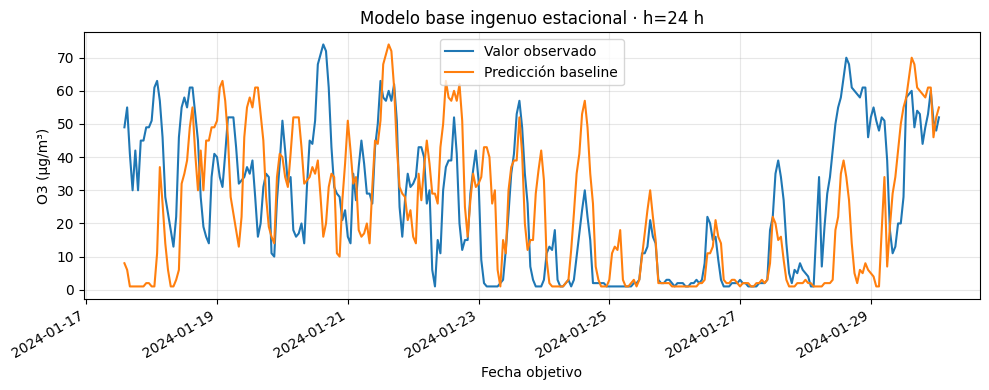

In [ ]:
# Inspección visual sobre un tramo continuo de predicciones

# Para obtener una buena figura de ejemplo, no conviene empezar necesariamente en el primer día
# del conjunto de validación, porque podrían existir huecos en la serie observada o
# en la referencia diaria utilizada por el modelo base.
#
# Entonces, se buscará automáticamente el primer bloque continuo de horas
# evaluables, es decir, un tramo donde existan tanto y_true como y_pred para
# todas las horas. Esta figura es solo ilustrativa; las métricas se calculan sobre todas
# las observaciones evaluables, no sobre este subconjunto.

EXAMPLE_HORIZON = 24
EXAMPLE_SPLIT = "validation"
EXAMPLE_HOURS = 300

example = baseline_predictions.loc[
    (baseline_predictions["horizon"] == EXAMPLE_HORIZON)
    & (baseline_predictions["split"] == EXAMPLE_SPLIT)
].copy()

example = example.sort_values("target_timestamp")

# Nos quedamos solo con las filas evaluables para la inspección visual:
# deben existir tanto el valor real como la predicción.
example_valid = example.dropna(subset=["y_true", "y_pred"]).copy()
example_valid = example_valid.sort_values("target_timestamp")

# Identificamos bloques continuos; un nuevo bloque empezará cuando la diferencia
# entre dos timestamps consecutivos no sea exactamente de una hora.
example_valid["delta_h"] = (
    example_valid["target_timestamp"].diff() / pd.Timedelta(hours=1)
)

example_valid["continuous_block"] = (
    example_valid["delta_h"].isna() | (example_valid["delta_h"] != 1)
).cumsum()

block_summary = (
    example_valid
    .groupby("continuous_block")
    .agg(
        start=("target_timestamp", "min"),
        end=("target_timestamp", "max"),
        n_hours=("target_timestamp", "count"),
    )
    .reset_index()
    .sort_values(["n_hours", "start"], ascending=[False, True])
)

display(block_summary.head(10))

# Se busca el primer bloque que tenga al menos "EXAMPLE_HOURS" horas.
candidate_blocks = block_summary.loc[block_summary["n_hours"] >= EXAMPLE_HOURS]

if candidate_blocks.empty:
    # Si no existe un tramo tan largo, se utiliza el bloque continuo que sea más largo.
    selected_block_id = block_summary.iloc[0]["continuous_block"]
    print(
        f"No se encontró un bloque continuo de {EXAMPLE_HOURS} horas. "
        "Se utilizará el bloque continuo más largo disponible."
    )
else:
    # Se toma el primer bloque continuo suficientemente largo en orden temporal.
    selected_block_id = candidate_blocks.sort_values("start").iloc[0]["continuous_block"]

example_zoom = example_valid.loc[
    example_valid["continuous_block"] == selected_block_id
].copy()

# Se limita el bloque a la longitud deseada.
example_zoom = example_zoom.head(EXAMPLE_HOURS)

print(
    "Tramo seleccionado para la inspección visual:",
    example_zoom["target_timestamp"].min(),
    "→",
    example_zoom["target_timestamp"].max(),
    f"({len(example_zoom)} horas)"
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_true"],
    label="Valor observado",
)

ax.plot(
    example_zoom["target_timestamp"],
    example_zoom["y_pred"],
    label="Predicción baseline",
)

ax.set_title(f"Modelo base ingenuo estacional - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel("O3 (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / f"fig_baseline_validation_zoom_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print(f"Figura guardada en: {figure_path}")

## Comprobaciones finales

Finalmente, se comprueba que:

- Se han generado las predicciones esperadas por horizonte
- No se han evaluado filas del conjunto de prueba
- Las métricas contienen los splits previstos
- Existen observaciones evaluables en calibración y validación


In [12]:
expected_prediction_files = [
    REPORTS_PREDICTIONS_DIR / f"{MODEL_NAME}_h{horizon:02d}.parquet"
    for horizon in HORIZONS_HOURS
]

missing_files = [path for path in expected_prediction_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Faltan archivos de predicciones: {missing_files}")

if not INCLUDE_TEST and "test" in set(baseline_predictions["split"]):
    raise AssertionError("Se han generado predicciones para test pese a INCLUDE_TEST=False.")

expected_splits = set(EVAL_SPLITS)
observed_splits = set(baseline_metrics["split"].unique())
missing_splits = expected_splits.difference(observed_splits)
if missing_splits:
    raise AssertionError(f"Faltan splits en las métricas: {missing_splits}")

if (baseline_metrics["n_evaluated"] <= 0).any():
    problem_rows = baseline_metrics.loc[baseline_metrics["n_evaluated"] <= 0]
    raise AssertionError(
        "Hay combinaciones horizonte/split sin observaciones evaluables:\n"
        f"{problem_rows}"
    )

print("Comprobaciones finales superadas correctamente.")
print("El modelo base queda listo para la posterior comparación puntual y para la calibración mediante split conformal.")


Comprobaciones finales superadas correctamente.
El modelo base queda listo para la posterior comparación puntual y para la calibración mediante split conformal.


## Salidas generadas

Este notebook genera las siguientes salidas principales:

```text
reports/predictions/baseline_seasonal_naive_h01.parquet
reports/predictions/baseline_seasonal_naive_h04.parquet
reports/predictions/baseline_seasonal_naive_h12.parquet
reports/predictions/baseline_seasonal_naive_h24.parquet

reports/tables/baseline_point_metrics.csv
reports/tables/baseline_prediction_summary.csv
reports/tables/baseline_causality_check.csv
reports/tables/baseline_predictions_sample.csv

reports/figures/fig_baseline_point_metrics_validation.png
reports/figures/fig_baseline_validation_zoom_h24.png
```

Estas predicciones se reutilizarán posteriormente para:

1. comparar el rendimiento puntual del modelo base con los modelos supervisados;
2. calibrar los intervalos del modelo base mediante `split conformal` a partir de los residuos absolutos observados en calibración.
